<a href="https://colab.research.google.com/github/GabriellaJovanka/churn-customer-prediction/blob/main/UAS_BENGKOD_(2)_FIX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAS Bengkel Koding Data Science
##Nama : Gabriella Jovanka Bustan
##NIM : A11.2023.14861

Dataset: `sales_marketing_customer_dataset.csv`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import joblib
from sklearn.model_selection import GridSearchCV, train_test_split

In [ ]:
# Load Dataset
df = pd.read_csv('sales_marketing_customer_dataset.csv')
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


### 1. Eksplorasi Data (EDA)

In [ ]:
# 1.1 Menampilkan 5 baris pertama
print("=== 5 Baris Pertama ===")
display(df.head())

=== 5 Baris Pertama ===


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [ ]:
# 1.1 Menampilkan informasi dataset
print("\n=== Informasi Dataset ===")
df.info()


=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  page

In [ ]:
# 1.1 Menampilkan statistik deskriptif dataset
print("\n=== Statistik Deskriptif ===")
display(df.describe())


=== Statistik Deskriptif ===


,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000



=== Persentase Missing Value ===
customer_id                      0
gender                         738
age                           1200
country                          0
city                             0
signup_date                      0
last_purchase_date               0
acquisition_channel              0
device_type                      0
subscription_type                0
is_premium_user                  0
total_visits                     0
avg_session_time                 0
pages_per_session                0
email_open_rate                  0
email_click_rate                 0
total_spent                   1050
avg_order_value                  0
discount_used                    0
coupon_code                   6133
support_tickets                  0
refund_requested                 0
delivery_delay_days              0
payment_method                   0
satisfaction_score             702
nps_score                        0
marketing_spend_per_user         0
lifetime_value       

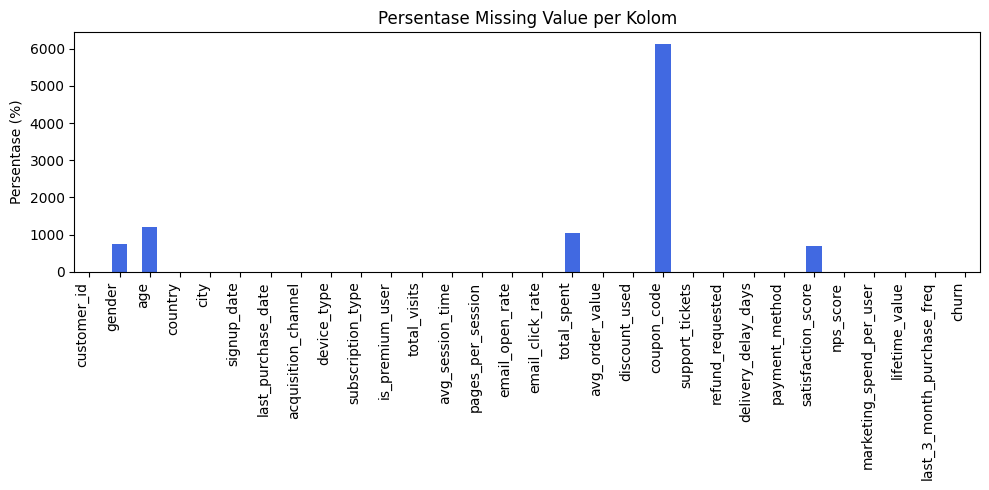

In [ ]:
# 1.2 Menghitung persentase missing value dalam visualisasi diagram batang
missing_percent = (df.isnull().sum())
print("\n=== Persentase Missing Value ===")
print(missing_percent)

plt.figure(figsize=(10, 5))
missing_percent.plot(kind='bar', color='royalblue')
plt.title('Persentase Missing Value per Kolom')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

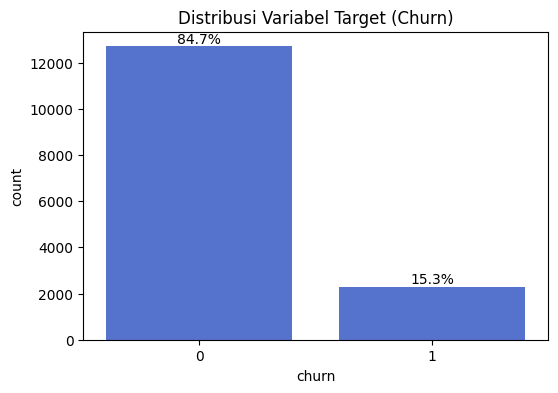

In [ ]:
# 1.3 Memvisualisasikan distribusi variabel target (Churn)
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='churn', data=df, color='royalblue')
plt.title('Distribusi Variabel Target (Churn)')

# Menambahkan label persentase di atas batang
total = float(len(df))
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

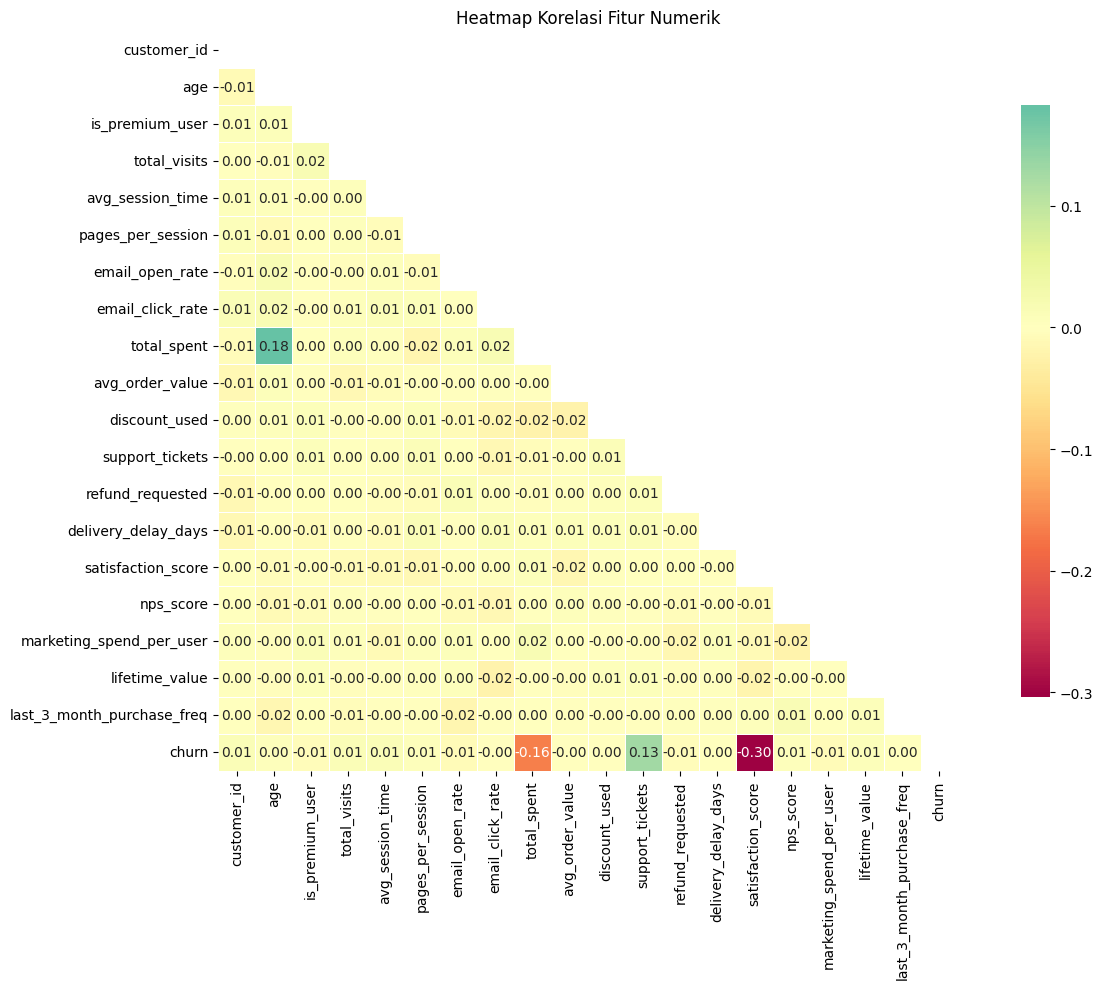


=== Korelasi Fitur terhadap Churn ===
churn                         1.000000
support_tickets               0.127910
total_visits                  0.013212
customer_id                   0.012208
avg_session_time              0.012198
lifetime_value                0.006250
pages_per_session             0.005871
nps_score                     0.005749
age                           0.004506
delivery_delay_days           0.001603
last_3_month_purchase_freq    0.001590
discount_used                 0.000265
avg_order_value              -0.001480
email_click_rate             -0.001752
is_premium_user              -0.005496
refund_requested             -0.006959
marketing_spend_per_user     -0.007315
email_open_rate              -0.008439
total_spent                  -0.163279
satisfaction_score           -0.303588
Name: churn, dtype: float64


In [ ]:
# 1.4 Heatmap korelasi fitur numerik
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True, # tampilkan angka korelasi
    fmt='.2f', # format 2 angka di belakang koma (atau pakai '.2e' kalau mau notasi seperti gambar)
    cmap='Spectral',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

# Identifikasi hubungan antar variabel yang berpotensi mempengaruhi pola churn pelanggan
print("\n=== Korelasi Fitur terhadap Churn ===")
print(corr['churn'].sort_values(ascending=False))

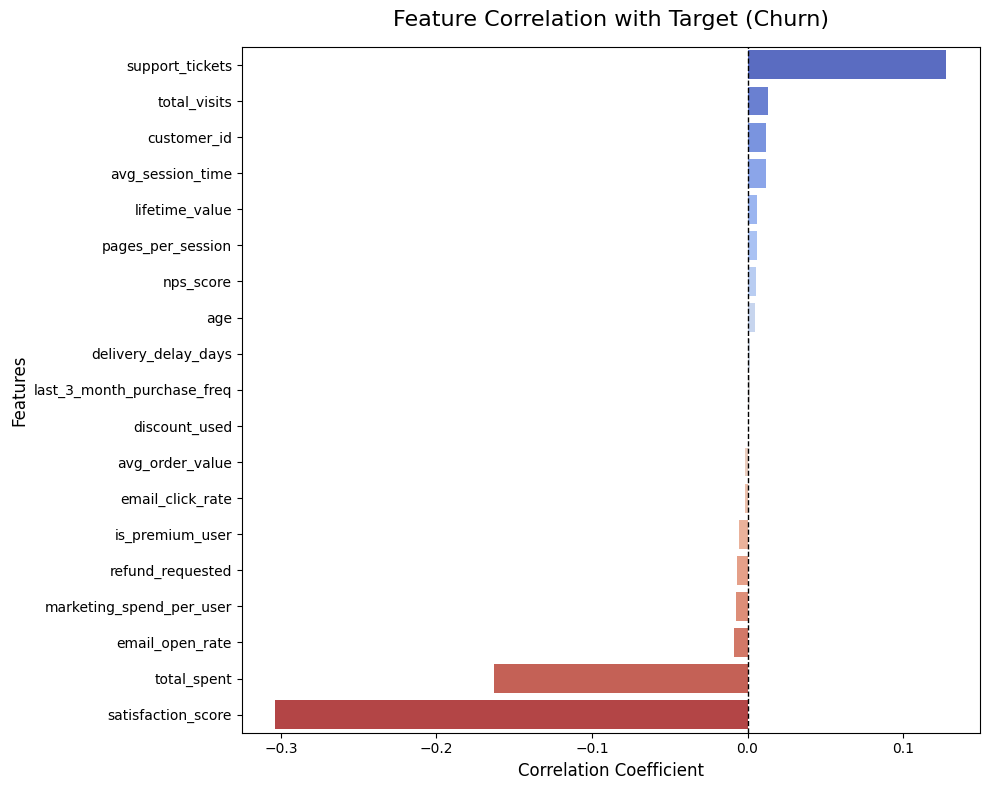

In [ ]:
# Visualisasi Feature Correlation with Target

# Ambil nilai korelasi terhadap 'churn'
# Gunakan .drop('churn') agar variabel churn tidak dikorelasikan dengan dirinya sendiri (yang nilainya pasti 1.0)
target_corr = corr['churn'].drop('churn').sort_values(ascending=False)

# Membuat Bar Chart
plt.figure(figsize=(10, 8))
sns.barplot(
    x=target_corr.values,
    y=target_corr.index,
    palette='coolwarm'
)

# Tampilan grafik
plt.title('Feature Correlation with Target (Churn)', fontsize=16, pad=15)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

### 2. Direct Modeling
Pemodelan tanpa preprocessing mendalam (Memakai data numerik dan membuang missing values)

In [ ]:
# Preprocessing instan untuk direct modeling hanya menggunakan data numerik
# dan membuang missing values pada data numerik
df_direct = numeric_df.dropna()

# 2.1 Menetapkan variabel target (y) yaitu kolom Churn,
# serta menggunakan seluruh kolom lain sebagai fitur prediktor (X)
X_direct = df_direct.drop('churn', axis=1)
y_direct = df_direct['churn']

In [ ]:
print("=== Missing Values Sebelum dropna() ===")
print(numeric_df.isnull().sum())
print("\nTotal missing values:", numeric_df.isnull().sum().sum())

print("\n=== Missing Values Sesudah dropna() ===")
print(df_direct.isnull().sum())
print("\nTotal missing values:", df_direct.isnull().sum().sum())

=== Missing Values Sebelum dropna() ===
customer_id                      0
age                           1200
is_premium_user                  0
total_visits                     0
avg_session_time                 0
pages_per_session                0
email_open_rate                  0
email_click_rate                 0
total_spent                   1050
avg_order_value                  0
discount_used                    0
support_tickets                  0
refund_requested                 0
delivery_delay_days              0
satisfaction_score             702
nps_score                        0
marketing_spend_per_user         0
lifetime_value                   0
last_3_month_purchase_freq       0
churn                            0
dtype: int64

Total missing values: 2952

=== Missing Values Sesudah dropna() ===
customer_id                   0
age                           0
is_premium_user               0
total_visits                  0
avg_session_time              0
pages_per_session 

In [ ]:
# 2.2 Train-test split
( X_train_dir,
X_test_dir,
y_train_dir,
y_test_dir ) = train_test_split(X_direct,
                              y_direct,
                              test_size=0.2,
                              random_state=42)

print("=== Distribusi Dataset ===")
print(f"Jumlah data sebelum split : {len(X_direct)}")
print(f"Jumlah data training      : {len(X_train_dir)}")
print(f"Jumlah data testing       : {len(X_test_dir)}")

print("\nPersentase:")
print(f"Training : {len(X_train_dir)/len(X_direct)*100:.1f}%")
print(f"Testing  : {len(X_test_dir)/len(X_direct)*100:.1f}%")

=== Distribusi Dataset ===
Jumlah data sebelum split : 12246
Jumlah data training      : 9796
Jumlah data testing       : 2450

Persentase:
Training : 80.0%
Testing  : 20.0%


In [ ]:
# 2.3 Mendefinisikan Model
models = {
    # Model Konvensional (LR)
    'Logistic Regression': LogisticRegression(max_iter=1000),

    # Model Ensemble Bagging (RF)
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),

    # Voting Classifier (LR + SVM + KNN)
    'Voting Classifier': VotingClassifier(estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('svm', SVC()),
        ('knn', KNeighborsClassifier())
    ], voting='hard')
}

=== Hasil Evaluasi Direct Modeling ===

--- Logistic Regression ---
Accuracy  : 0.8371
Precision : 0.5660
Recall    : 0.1453
F1-Score  : 0.2312
--- Random Forest ---
Accuracy  : 0.8400
Precision : 0.5439
Recall    : 0.3148
F1-Score  : 0.3988
--- Voting Classifier ---
Accuracy  : 0.8335
Precision : 0.5758
Recall    : 0.0460
F1-Score  : 0.0852


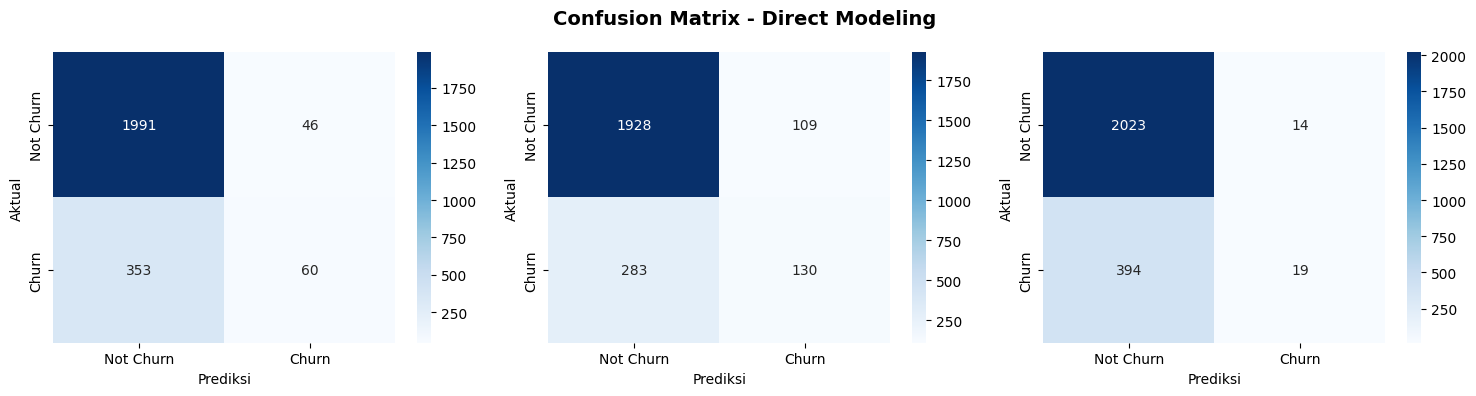

In [ ]:
# List kosong untuk menyimpan hasil evaluasi ke dalam tabel nanti
evaluation_results = []

# 2.4 & 2.5 Melatih dan Mengevaluasi Model
print("=== Hasil Evaluasi Direct Modeling ===\n")
for name, model in models.items():
    model.fit(X_train_dir, y_train_dir)
    y_pred = model.predict(X_test_dir)

    print(f"--- {name} ---")
    print(f"Accuracy  : {accuracy_score(y_test_dir, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test_dir, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test_dir, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_test_dir, y_pred):.4f}")

# Plotting Confusion Matrix semua model sekaligus
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_dir)

    # Plotting Confusion Matrix
    cm = confusion_matrix(y_test_dir, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')

plt.suptitle('Confusion Matrix - Direct Modeling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Modeling dengan Preprocessing
Melakukan Handling Missing Value, Encoding, dan Feature Scaling

In [ ]:
df_prep = df.copy()

# Cek missing values SEBELUM imputasi
missing_before = df_prep.isnull().sum()

# 3.1.a Penanganan Missing Value (Imputasi untuk sisa kolom)
for col in df_prep.columns:
    if df_prep[col].dtype == 'object':
        df_prep[col] = df_prep[col].fillna(df_prep[col].mode()[0])
    else:
        df_prep[col] = df_prep[col].fillna(df_prep[col].median())

# Cek missing values SETELAH imputasi
missing_after = df_prep.isnull().sum()

# Gabungkan menjadi satu tabel (kiri dan kanan)
missing_summary = pd.DataFrame({
    'Sebelum Imputasi': missing_before,
    'Setelah Imputasi': missing_after
})

# Tampilkan tabel secara lengkap
print("=== Ringkasan Missing Values ===")
print(missing_summary.to_string())

=== Ringkasan Missing Values ===
                            Sebelum Imputasi  Setelah Imputasi
customer_id                                0                 0
gender                                   738                 0
age                                     1200                 0
country                                    0                 0
city                                       0                 0
signup_date                                0                 0
last_purchase_date                         0                 0
acquisition_channel                        0                 0
device_type                                0                 0
subscription_type                          0                 0
is_premium_user                            0                 0
total_visits                               0                 0
avg_session_time                           0                 0
pages_per_session                          0                 0
email_open_rate       

In [ ]:
# 3.1.b Penanganan Duplikasi
print("Jumlah duplikasi sebelum:", df_prep.duplicated().sum())
df_prep = df_prep.drop_duplicates()

Jumlah duplikasi sebelum: 0


In [ ]:
def count_outliers(dataframe, columns):
    outlier_dict = {}
    for col in columns:
        if col in dataframe.columns:
            Q1 = dataframe[col].quantile(0.25)
            Q3 = dataframe[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            n_outliers = ((dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)).sum()
            if n_outliers > 0:
                outlier_dict[col] = n_outliers
    return outlier_dict

# Definisikan sekali saja di awal
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('churn', errors='ignore')

# SEBELUM handling — dari df asli
outliers_before = count_outliers(df, numeric_cols)
print("=== Outlier SEBELUM Handling ===")
for col, n in outliers_before.items():
    print(f"{col:<30} : {n} outlier")
print(f"\nTotal kolom dengan outlier : {len(outliers_before)}")
print(f"Total outlier              : {sum(outliers_before.values())}")

# 3.1.c Penanganan Outlier (Menggunakan metode batas IQR/Capping)
for col in numeric_cols:
    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_prep[col] = np.where(df_prep[col] > upper_bound, upper_bound,
                   np.where(df_prep[col] < lower_bound, lower_bound, df_prep[col]))

# SESUDAH handling — dari df_prep
outliers_after = count_outliers(df_prep, numeric_cols)
print("\n=== Outlier SESUDAH Handling ===")
if len(outliers_after) == 0:
    print("Tidak ada outlier tersisa.")
else:
    for col, n in outliers_after.items():
        print(f"{col:<30} : {n} outlier")
print(f"\nTotal kolom dengan outlier : {len(outliers_after)}")

=== Outlier SEBELUM Handling ===
age                            : 89 outlier
total_visits                   : 39 outlier
avg_session_time               : 45 outlier
pages_per_session              : 33 outlier
total_spent                    : 78 outlier
avg_order_value                : 54 outlier
support_tickets                : 79 outlier
refund_requested               : 2215 outlier
delivery_delay_days            : 184 outlier
satisfaction_score             : 753 outlier
lifetime_value                 : 56 outlier

Total kolom dengan outlier : 11
Total outlier              : 3625

=== Outlier SESUDAH Handling ===
Tidak ada outlier tersisa.

Total kolom dengan outlier : 0


In [ ]:
# 3.1.d FEATURE ENGINEERING (Rekayasa Fitur Baru)
# Ambil dari df asli jika kolom tanggal sudah hilang dari df_prep
for col in ['signup_date', 'last_purchase_date']:
    if col not in df_prep.columns:
        df_prep[col] = df['signup_date'] if col == 'signup_date' else df['last_purchase_date']


# Ubah kolom menjadi format datetime
df_prep['signup_date'] = pd.to_datetime(df_prep['signup_date'], errors='coerce')
df_prep['last_purchase_date'] = pd.to_datetime(df_prep['last_purchase_date'], errors='coerce')

# Buat fitur baru: tenure_days (Lama pelanggan menggunakan layanan dalam hitungan hari)
df_prep['tenure_days'] = (df_prep['last_purchase_date'] - df_prep['signup_date']).dt.days

In [ ]:
# Menampilkan nilai unik dari semua kolom kategorikal (selain kolom signup_date dan last_purchased_date)
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols = categorical_cols.drop(['signup_date', 'last_purchase_date'], errors='ignore')

print("=== Nilai Unik Kolom Kategorik selain kolom signup_date dan last_purchased_date ===\n")
for col in categorical_cols:
    unique_vals = sorted(df[col].dropna().unique())
    df_unique = pd.DataFrame({
        'No': range(1, len(unique_vals) + 1),
        'Nilai Unik': unique_vals,
        'Jumlah Data': [df[col].value_counts()[val] for val in unique_vals]
    })
    print(f"📌 {col} ({len(unique_vals)} nilai unik):")
    print(df_unique.to_string(index=False))
    print()

=== Nilai Unik Kolom Kategorik selain kolom signup_date dan last_purchased_date ===

📌 gender (3 nilai unik):
 No Nilai Unik  Jumlah Data
  1     Female         6686
  2       Male         6844
  3      Other          732

📌 country (5 nilai unik):
 No Nilai Unik  Jumlah Data
  1 Bangladesh         2984
  2    Germany         3072
  3      India         3014
  4         UK         2955
  5        USA         2975

📌 city (7 nilai unik):
 No Nilai Unik  Jumlah Data
  1     Berlin         2075
  2      Delhi         2128
  3      Dhaka         2178
  4    Hamburg         2064
  5     London         2236
  6     Mumbai         2184
  7   New York         2135

📌 acquisition_channel (5 nilai unik):
 No   Nilai Unik  Jumlah Data
  1        Email         2933
  2 Facebook Ads         3024
  3   Google Ads         3047
  4      Organic         3055
  5     Referral         2941

📌 device_type (3 nilai unik):
 No Nilai Unik  Jumlah Data
  1    Desktop         4960
  2     Mobile         4997
 

In [ ]:
# Menampilkan nilai unik dari kolom kategorikal (hanya signup_date dan last_purchased_date)
date_cols = ['signup_date', 'last_purchase_date']

print("=== Nilai Unik Kolom Kategorik (hanya kolom signup_date dan last_purchased_date) ===\n")
for col in date_cols:
    df[col] = pd.to_datetime(df[col])
    print(f"📌 {col}")
    print(f"   Tanggal Paling Awal  : {df[col].min()}")
    print(f"   Tanggal Paling Akhir : {df[col].max()}")
    print(f"   Jumlah Nilai Unik    : {df[col].nunique()}")
    print()

=== Nilai Unik Kolom Kategorik (hanya kolom signup_date dan last_purchased_date) ===

📌 signup_date
   Tanggal Paling Awal  : 2022-01-01 00:00:00
   Tanggal Paling Akhir : 2024-09-26 00:00:00
   Jumlah Nilai Unik    : 1000

📌 last_purchase_date
   Tanggal Paling Awal  : 2023-01-01 00:00:00
   Tanggal Paling Akhir : 2025-03-10 00:00:00
   Jumlah Nilai Unik    : 800



In [ ]:
# 3.1.e HYBRID ENCODING (Label Encoding + OHE)

# Menampilkan daftar nilai unik untuk setiap kolom
print("=== Daftar Nilai Unik per Kolom ===")
all_cols_to_check = ['city', 'coupon_code', 'subscription_type', 'gender',
                     'country', 'acquisition_channel', 'device_type', 'payment_method']

for col in all_cols_to_check:
    if col in df_prep.columns:
        # Mengambil nilai unik dan mengurutkannya secara alfabetis
        unique_vals = sorted([str(val) for val in df_prep[col].dropna().unique()])
        print(f"\n📌 Kolom '{col}' memiliki {len(unique_vals)} nilai unik:")
        print(", ".join(unique_vals))

print("\n" + "="*100 + "\n")

# 1. Label Encoding — menampilkan mapping
print("=== Mapping Label Encoding ===")
le_cols = ['city', 'coupon_code', 'subscription_type']

for col in le_cols:
    if col in df_prep.columns:
        le = LabelEncoder()
        le.fit(df_prep[col].astype(str))

        mapping = {label: idx for idx, label in enumerate(le.classes_)}

        print(f"\n📌 {col} (Label Encoding):")
        for label, idx in mapping.items():
            print(f"{label} = {idx}")

        # Terapkan encoding
        df_prep[col] = le.transform(df_prep[col].astype(str))

# 2. One-Hot Encoding — tampilkan kolom hasil OHE
ohe_cols = ['gender', 'country', 'acquisition_channel', 'device_type', 'payment_method']
ohe_cols_existing = [col for col in ohe_cols if col in df_prep.columns]

# Terapkan OHE
df_prep = pd.get_dummies(df_prep, columns=ohe_cols_existing, drop_first=False)

=== Daftar Nilai Unik per Kolom ===

📌 Kolom 'city' memiliki 7 nilai unik:
Berlin, Delhi, Dhaka, Hamburg, London, Mumbai, New York

📌 Kolom 'coupon_code' memiliki 3 nilai unik:
NEW20, REF10, SALE15

📌 Kolom 'subscription_type' memiliki 2 nilai unik:
Annual, Monthly

📌 Kolom 'gender' memiliki 3 nilai unik:
Female, Male, Other

📌 Kolom 'country' memiliki 5 nilai unik:
Bangladesh, Germany, India, UK, USA

📌 Kolom 'acquisition_channel' memiliki 5 nilai unik:
Email, Facebook Ads, Google Ads, Organic, Referral

📌 Kolom 'device_type' memiliki 3 nilai unik:
Desktop, Mobile, Tablet

📌 Kolom 'payment_method' memiliki 5 nilai unik:
BKash, Card, PayPal, SEPA, UPI


=== Mapping Label Encoding ===

📌 city (Label Encoding):
Berlin = 0
Delhi = 1
Dhaka = 2
Hamburg = 3
London = 4
Mumbai = 5
New York = 6

📌 coupon_code (Label Encoding):
NEW20 = 0
REF10 = 1
SALE15 = 2

📌 subscription_type (Label Encoding):
Annual = 0
Monthly = 1


In [ ]:
# Visualisasi Tabel Terpisah untuk Setiap Kolom OHE
target_ohe_cols = ['gender', 'country', 'acquisition_channel', 'device_type', 'payment_method']
sample_size = 5

for col in target_ohe_cols:
    # Cek apakah kolom tersebut ada di dataset asli (df)
    if col in df.columns:
        print(f"\n" + "="*50)
        print(f"TABEL TRANSFORMASI: {col.upper()}")
        print("="*50)

        # Tabel Sisi Kiri = Data Asli
        print(f"Data Asli ('{col}') :")
        print(df[col].head(sample_size).to_string(index=False))

        # Tabel Sisi Kanan = Hasil OHE
        # Cari semua kolom di df_prep yang nama depannya adalah nama kolom tersebut
        ohe_cols_result = [c for c in df_prep.columns if c.startswith(f"{col}_")]

        print(f"\nHasil One-Hot Encoding :")
        # Menampilkan tabel hasil OHE (menggunakan reset_index)
        print(df_prep[ohe_cols_result].head(sample_size).to_string(index=False))
        print("\n")
    else:
        print(f"\nKolom '{col}' tidak ditemukan di dataset.")


TABEL TRANSFORMASI: GENDER
Data Asli ('gender') :
  Male
   NaN
Female
Female
  Male

Hasil One-Hot Encoding :
 gender_Female  gender_Male  gender_Other
         False         True         False
         False         True         False
          True        False         False
          True        False         False
         False         True         False



TABEL TRANSFORMASI: COUNTRY
Data Asli ('country') :
  India
Germany
Germany
  India
    USA

Hasil One-Hot Encoding :
 country_Bangladesh  country_Germany  country_India  country_UK  country_USA
              False            False           True       False        False
              False             True          False       False        False
              False             True          False       False        False
              False            False           True       False        False
              False            False          False       False         True



TABEL TRANSFORMASI: ACQUISITION_CHANNEL
Data Asli 

In [ ]:
print("\n--- Informasi Dataset Saat Ini ---\n")
print(df_prep.info())


--- Informasi Dataset Saat Ini ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 47 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   customer_id                       15000 non-null  float64       
 1   age                               15000 non-null  float64       
 2   city                              15000 non-null  int64         
 3   signup_date                       15000 non-null  datetime64[ns]
 4   last_purchase_date                15000 non-null  datetime64[ns]
 5   subscription_type                 15000 non-null  int64         
 6   is_premium_user                   15000 non-null  float64       
 7   total_visits                      15000 non-null  float64       
 8   avg_session_time                  15000 non-null  float64       
 9   pages_per_session                 15000 non-null  float64       
 10  email_ope

In [ ]:
# 3.1.f Hapus fitur tanggal dan ID karena informasinya sudah berhasil diekstrak
df_prep = df_prep.drop(['customer_id', 'signup_date', 'last_purchase_date'], axis=1, errors='ignore')
print("Fitur baru 'tenure_days' berhasil ditambahkan!")

Fitur baru 'tenure_days' berhasil ditambahkan!


In [ ]:
# 3.1.g Menetapkan fitur (X) dan target (y)
X_prep = df_prep.drop('churn', axis=1)
y_prep = df_prep['churn']

# Train-test split
(X_train_prep,
 X_test_prep,
 y_train_prep,
 y_test_prep) = train_test_split(X_prep,
                                 y_prep,
                                 test_size=0.2,
                                 random_state=42)

print("=== Train-Test Split (Preprocessing) ===")
print(f"   Jumlah data keseluruhan : {len(X_prep)}")
print(f"   Data training           : {len(X_train_prep)} baris (80%)")
print(f"   Data testing            : {len(X_test_prep)} baris (20%)")

# 3.1.h PENERAPAN SMOTE (Hanya pada Data Training)
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_prep, y_train_prep)

=== Train-Test Split (Preprocessing) ===
   Jumlah data keseluruhan : 15000
   Data training           : 12000 baris (80%)
   Data testing            : 3000 baris (20%)


In [ ]:
# Informasi Train-Test Split
print("=== Train test split 80:20 ===")
print(f"   Data training  : {len(X_train_prep)} baris (80%)")
print(f"   Data testing   : {len(X_test_prep)} baris (20%)")

# Distribusi kelas pada data training
print("\n=== Distribusi kelas pada data training : ===")
train_dist = y_train_prep.value_counts()
print(f"   churn (1)     : {train_dist.get(1, 0)}")
print(f"   not churn (0) : {train_dist.get(0, 0)}")

# Distribusi kelas pada data testing
print("\n=== Distribusi kelas pada data testing : ===")
test_dist = y_test_prep.value_counts()
print(f"   churn (1)     : {test_dist.get(1, 0)}")
print(f"   not churn (0) : {test_dist.get(0, 0)}")

# Informasi Sebelum dan Setelah SMOTE
print("\n" + "="*100)
print(f"Sebelum SMOTE : {len(X_train_prep)} sampel")
print(f"Setelah SMOTE : {len(X_train_smote)} sampel")

# Distribusi kelas setelah SMOTE
print("\nDistribusi kelas :")
smote_dist = y_train_smote.value_counts()
print(f"   churn (1)     : {smote_dist.get(1, 0)}")
print(f"   not churn (0) : {smote_dist.get(0, 0)}")

=== Train test split 80:20 ===
   Data training  : 12000 baris (80%)
   Data testing   : 3000 baris (20%)

=== Distribusi kelas pada data training : ===
   churn (1)     : 1854
   not churn (0) : 10146

=== Distribusi kelas pada data testing : ===
   churn (1)     : 444
   not churn (0) : 2556

Sebelum SMOTE : 12000 sampel
Setelah SMOTE : 20292 sampel

Distribusi kelas :
   churn (1)     : 10146
   not churn (0) : 10146


In [ ]:
# 3.1.i Scaling (Sangat penting untuk SVM dan KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test_prep)

In [ ]:
# 3.3 Mendefinisikan Model (Sesuai permintaan terbaru)
# Pastikan model ini di-inisialisasi sebelum loop evaluasi
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Voting Classifier': VotingClassifier(estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('svm', SVC()),
        ('knn', KNeighborsClassifier())
    ], voting='hard')
}

In [ ]:
# 3.4 Evaluasi Model (Looping untuk setiap model yang didefinisikan)
print("\n=== Hasil Evaluasi Modeling dengan Preprocessing + SMOTE + Feature Engineering ===")
for name, model in models.items():
    # Melatih model menggunakan data training yang sudah di-SMOTE dan di-Scaling
    model.fit(X_train_scaled, y_train_smote)

    # Memprediksi data test (sudah di-scale)
    y_pred = model.predict(X_test_scaled)

    print(f"--- {name} ---")
    print(f"Accuracy  : {accuracy_score(y_test_prep, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test_prep, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test_prep, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_test_prep, y_pred):.4f}\n")


=== Hasil Evaluasi Modeling dengan Preprocessing + SMOTE + Feature Engineering ===
--- Logistic Regression ---
Accuracy  : 0.8530
Precision : 0.5087
Recall    : 0.1982
F1-Score  : 0.2853

--- Random Forest ---
Accuracy  : 0.8537
Precision : 0.5054
Recall    : 0.5270
F1-Score  : 0.5160

--- Voting Classifier ---
Accuracy  : 0.8500
Precision : 0.4483
Recall    : 0.0586
F1-Score  : 0.1036



### 4. Hyperparameter Tuning & Feature Selection
Asumsi Random Forest adalah model terbaik, kita lakukan optimasi.

--- 1. Analisis Feature Importance ---


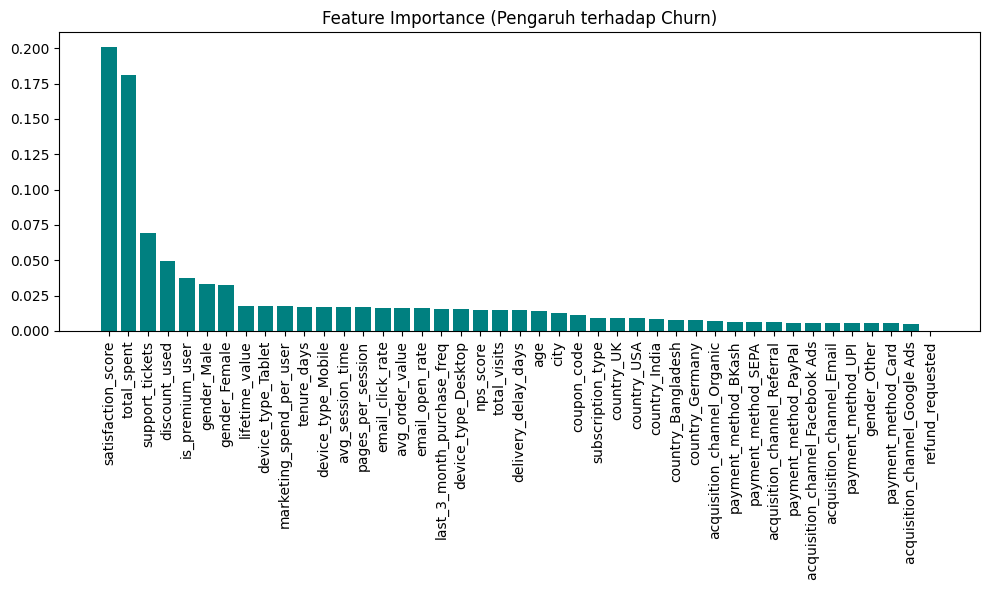


--- 2. Hyperparameter Tuning (Kompetisi 3 Strategi) ---
Sedang melakukan tuning pada: Model Konvensional (LR)...
Sedang melakukan tuning pada: Model Bagging (RF)...
Sedang melakukan tuning pada: Model Voting Classifier...

--- JUARA STRATEGI: Bagging (RF) ---
Best Parameters: {'max_depth': 10, 'n_estimators': 100}

--- 5. Melatih kembali Bagging (RF) dengan data latih optimal ---

--- 6. Evaluasi Performa Bagging (RF) ---
Accuracy  : 0.8473
Precision : 0.4886
Recall    : 0.6734
F1-Score  : 0.5663


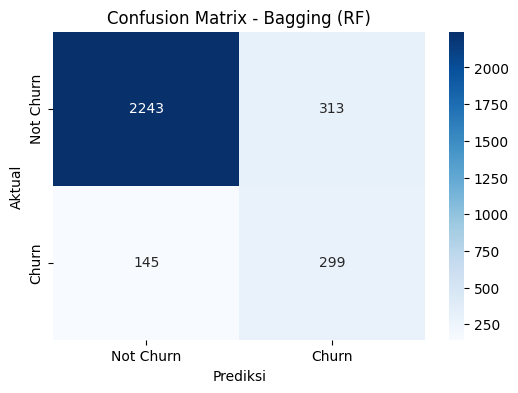

In [ ]:
# =====================================================================
# 1. Analisis Feature Importance (Menggunakan RF sebagai Explainer)
# =====================================================================
print("--- 1. Analisis Feature Importance ---")
rf_temp = RandomForestClassifier(random_state=42)
rf_temp.fit(X_train_scaled, y_train_smote)

importances = rf_temp.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_prep.columns

plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Pengaruh terhadap Churn)")
plt.bar(range(X_train_scaled.shape[1]), importances[indices], color='teal')
plt.xticks(range(X_train_scaled.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

# =====================================================================
# 2. Hyperparameter Tuning (Kompetisi 3 Strategi)
# =====================================================================
print("\n--- 2. Hyperparameter Tuning (Kompetisi 3 Strategi) ---")

# A. Konvensional (Logistic Regression)
model_a = LogisticRegression(max_iter=2000)
params_a = {'C': [0.1, 1, 10]}

# B. Ensemble Bagging (Random Forest)
model_b = RandomForestClassifier(random_state=42)
params_b = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10]}

# C. Voting Classifier (LR + SVM + KNN)
model_c = VotingClassifier(estimators=[
    ('lr', LogisticRegression(max_iter=2000)),
    ('svm', SVC(probability=True)),
    ('knn', KNeighborsClassifier())
], voting='soft', weights=[2, 1, 1])
params_c = {
    'weights': [[1, 1, 1], [2, 1, 1], [1, 2, 1]],
    'lr__C': [0.1, 1],
    'svm__C': [0.1, 1],
    # 'knn__n_neighbors': [3, 5]
}

def get_best_model(model, params, name):
    print(f"Sedang melakukan tuning pada: {name}...")
    grid = GridSearchCV(model, params, cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train_scaled, y_train_smote)
    return grid.best_estimator_, grid.best_score_, grid.best_params_

best_a, score_a, param_a = get_best_model(model_a, params_a, "Model Konvensional (LR)")
best_b, score_b, param_b = get_best_model(model_b, params_b, "Model Bagging (RF)")
best_c, score_c, param_c = get_best_model(model_c, params_c, "Model Voting Classifier")

# =====================================================================
# 3 & 4. Penentuan Best Estimator
# =====================================================================
results = [('Konvensional (LR)', score_a, best_a, param_a),
           ('Bagging (RF)', score_b, best_b, param_b),
           ('Voting Classifier', score_c, best_c, param_c)]

best_strategy = max(results, key=lambda item: item[1])
print(f"\n--- JUARA STRATEGI: {best_strategy[0]} ---")
print(f"Best Parameters: {best_strategy[3]}")

# =====================================================================
# 5. Melatih Kembali (Refitting) Best Estimator
# =====================================================================
best_model_final = best_strategy[2]
print(f"\n--- 5. Melatih kembali {best_strategy[0]} dengan data latih optimal ---")
best_model_final.fit(X_train_scaled, y_train_smote)

# =====================================================================
# 6. Evaluasi Performa Model Optimal
# =====================================================================
print(f"\n--- 6. Evaluasi Performa {best_strategy[0]} ---")
y_pred_final = best_model_final.predict(X_test_scaled)

print(f"Accuracy  : {accuracy_score(y_test_prep, y_pred_final):.4f}")
print(f"Precision : {precision_score(y_test_prep, y_pred_final):.4f}")
print(f"Recall    : {recall_score(y_test_prep, y_pred_final):.4f}")
print(f"F1-Score  : {f1_score(y_test_prep, y_pred_final):.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_prep, y_pred_final), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_strategy[0]}')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()


--- Tabel Perbandingan Metrik Evaluasi ---
            Model  Accuracy  Precision   Recall  F1-Score
Konvensional (LR)  0.852333   0.502959 0.191441  0.277325
     Bagging (RF)  0.847333   0.488562 0.673423  0.566288
Voting Classifier  0.853667   0.522523 0.130631  0.209009


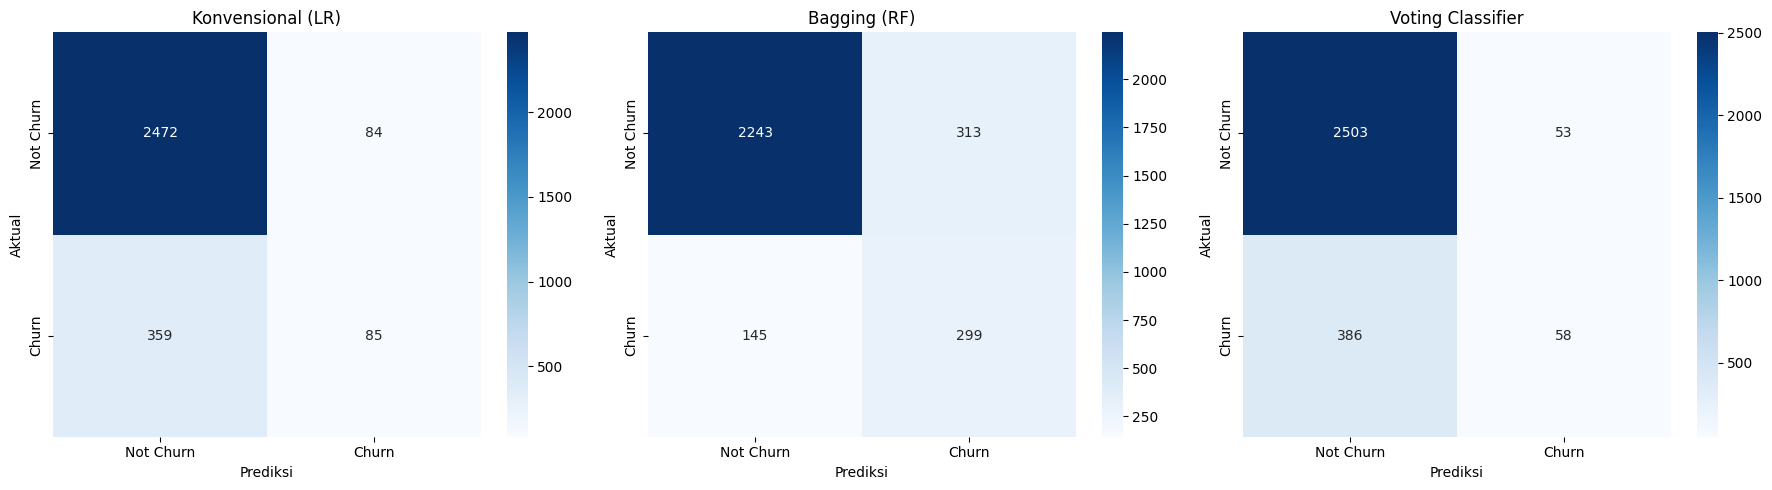

In [ ]:
# =====================================================================
# Evaluasi Perbandingan Menyeluruh (3 Model)
# =====================================================================
print("\n--- Tabel Perbandingan Metrik Evaluasi ---")

# Daftar model untuk dievaluasi
models_to_eval = [
    ('Konvensional (LR)', best_a),
    ('Bagging (RF)', best_b),
    ('Voting Classifier', best_c)
]

# List untuk menampung hasil
results_table = []

# Membuat plot untuk Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models_to_eval):
    y_pred = model.predict(X_test_scaled)

    # Menghitung Metrik
    acc = accuracy_score(y_test_prep, y_pred)
    prec = precision_score(y_test_prep, y_pred)
    rec = recall_score(y_test_prep, y_pred)
    f1 = f1_score(y_test_prep, y_pred)

    results_table.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

    # Plotting Confusion Matrix
    cm = confusion_matrix(y_test_prep, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')

# Menampilkan Tabel
df_results = pd.DataFrame(results_table)
print(df_results.to_string(index=False))

plt.tight_layout()
plt.show()

### 5. Deployment: Menyimpan Model

In [ ]:
# Simpan model untuk Deployment
joblib.dump(best_model_final, 'best_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\nModel juara telah disimpan sebagai 'best_churn_model.pkl'!")


Model juara telah disimpan sebagai 'best_churn_model.pkl'!
